# Our RGB+IR Fusion Model(RGB Pretraining)

In [ ]:
# Install dependencies
!pip install torch torchvision pytorch_wavelets timm
!pip install pycocotools tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.6 MB/s eta 0:00:00



Imports and Dependencies

This section loads all required libraries for:
- Data processing (NumPy, OpenCV)
- Visualization (Matplotlib)
- Deep learning (PyTorch, timm)
- Dataset handling (COCO API)
- Wavelet transforms (DWT)

In [ ]:
# Standard Library Imports
import os
import random
import shutil
import zipfile
import warnings
import logging

# Third-Party Imports
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


# PyTorch Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.ops as ops




# External ML Libraries
import timm
from pycocotools.coco import COCO
from pytorch_wavelets import DWTForward


# suppress timm warnings (correct logger)
logging.getLogger("timm.models._builder").setLevel(logging.ERROR)

# suppress PyTorch scheduler warning
warnings.filterwarnings(
    "ignore",
    message="Detected call of `lr_scheduler.step()` before `optimizer.step()`"
)


## Downloading COCO Dataset and Necessary File Operations

In [ ]:
# Paths & Setup
DATA_DIR = "/content/drive/MyDrive/coco"
os.makedirs(DATA_DIR, exist_ok=True)
os.chdir(DATA_DIR)


#### Download COCO Dataset


In [ ]:
# images (train)
!wget -c http://images.cocodataset.org/zips/train2017.zip

# images (val)
!wget -c http://images.cocodataset.org/zips/val2017.zip

# annotations
!wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip

--2026-05-04 05:25:12--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.115.129, 3.5.11.135, 16.15.183.229, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.115.129|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  60.2MB/s    in 5m 34s  

2026-05-04 05:30:46 (55.2 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2026-05-04 05:30:46--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.83.148, 54.231.196.217, 16.15.252.151, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.83.148|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 


#### Unzip and Copy Files

In [ ]:
SRC = "/content/drive/MyDrive/coco"
DST = "/content/coco"

if not os.path.exists(DST):
    print("Copying COCO to local disk")
    shutil.copytree(SRC, DST)
else:
    print("COCO already copied")

Copying COCO to local disk


In [ ]:
EXTRACT_DIR = "/content/coco"
def unzip(file):
    with zipfile.ZipFile(file, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

unzip("train2017.zip")
unzip("val2017.zip")
unzip("annotations_trainval2017.zip")

## Data Augmentations


### 🧠 COCO Person Dataset

This dataset class loads and processes the COCO dataset specifically for **person detection**.

### Key Features

- 📦 Uses COCO API to load images and annotations
- 🧍 Filters only **person class**
- 🧹 Removes very small objects (noise reduction)
- 🔀 Applies strong augmentations:
  - Mosaic augmentation (50%)
  - Affine transform
  - Horizontal flip
  - HSV color jitter
- 🌡️ Optional IR (infrared) simulation
- ⚡ Returns PyTorch tensors ready for training

---

### 📐 Bounding Box Format

We use YOLO format:

(class, x_center, y_center, width, height)

- All values are normalized between 0 and 1
- Class is always 0 (person)

---

### 🎯 Goal

Improve robustness for:
- different scales
- occlusions
- lighting conditions
- crowded scenes

In [ ]:
# BOX FORMAT CONVERSIONS
def xywh_to_xyxy(box, w, h):
    """
    Convert YOLO format → pixel corner format

    (xc, yc, bw, bh) → (x1, y1, x2, y2)
    """
    xc, yc, bw, bh = box
    xc *= w
    yc *= h
    bw *= w
    bh *= h

    x1 = xc - bw / 2
    y1 = yc - bh / 2
    x2 = xc + bw / 2
    y2 = yc + bh / 2

    return np.array([x1, y1, x2, y2])


def xyxy_to_xywh(box, w, h):
    """
    Convert pixel corner format → YOLO format
    """
    x1, y1, x2, y2 = box

    bw = x2 - x1
    bh = y2 - y1

    xc = x1 + bw / 2
    yc = y1 + bh / 2

    return np.array([xc / w, yc / h, bw / w, bh / h])



In [ ]:
# RANDOM ROTATION
def random_rotate(image, boxes, angle_range=30):
    """
    Rotate image and update bounding boxes.

    - Rotation is centered
    - Boxes are recalculated using rotated corner points
    """
    angle = random.uniform(-angle_range, angle_range)
    h, w = image.shape[:2]

    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h))

    if len(boxes) == 0:
        return rotated, boxes

    new_boxes = []

    for b in boxes:
        cls, xc, yc, bw, bh = b

         # Convert to pixel box
        box_xyxy = xywh_to_xyxy([xc, yc, bw, bh], w, h)

        # Get 4 corners
        x1, y1, x2, y2 = box_xyxy

        corners = np.array([
            [x1, y1],
            [x2, y1],
            [x2, y2],
            [x1, y2]
        ])

        # Apply rotation
        corners = np.hstack([corners, np.ones((4,1))])
        rotated_corners = (M @ corners.T).T

        # Rebuild box
        x_coords = rotated_corners[:,0]
        y_coords = rotated_corners[:,1]

        x1_new = np.clip(x_coords.min(), 0, w)
        y1_new = np.clip(y_coords.min(), 0, h)
        x2_new = np.clip(x_coords.max(), 0, w)
        y2_new = np.clip(y_coords.max(), 0, h)

        # Skip invalid boxes
        if (x2_new - x1_new) < 2 or (y2_new - y1_new) < 2:
            continue

        new_box = xyxy_to_xywh([x1_new, y1_new, x2_new, y2_new], w, h)
        new_boxes.append([cls, *new_box])

    if len(new_boxes) == 0:
        return rotated, torch.zeros((0,5))

    return rotated, torch.tensor(new_boxes, dtype=torch.float32)

In [ ]:
# HORIZONTAL FLIP
def horizontal_flip(image, boxes, p=0.5):
    """
    Flip image horizontally and adjust x-center.
    """
    if random.random() > p:
        return image, boxes

    image = cv2.flip(image, 1)

    new_boxes = []
    for b in boxes:
        cls, xc, yc, bw, bh = b
        xc = 1 - xc
        xc = np.clip(xc, 0, 1)
        new_boxes.append([cls, xc, yc, bw, bh])

    return image, torch.tensor(new_boxes, dtype=torch.float32)

In [ ]:
# RANDOM AFFINE
def random_affine(image, boxes, scale=(0.8, 1.2), translate=0.2):
    """
    Apply scaling + translation.
    """
    h, w = image.shape[:2]

    scale_factor = random.uniform(*scale)
    tx = random.uniform(-translate, translate) * w
    ty = random.uniform(-translate, translate) * h

    M = np.array([
        [scale_factor, 0, tx],
        [0, scale_factor, ty]
    ])

    transformed = cv2.warpAffine(image, M, (w, h))

    if len(boxes) == 0:
        return transformed, boxes

    new_boxes = []

    for b in boxes:
        cls, xc, yc, bw, bh = b
        box = xywh_to_xyxy([xc, yc, bw, bh], w, h)

        x1, y1, x2, y2 = box

        corners = np.array([
            [x1, y1],
            [x2, y1],
            [x2, y2],
            [x1, y2]
        ])

        corners = np.hstack([corners, np.ones((4,1))])
        transformed_corners = (M @ corners.T).T

        x_coords = transformed_corners[:,0]
        y_coords = transformed_corners[:,1]

        x1_new = np.clip(x_coords.min(), 0, w)
        y1_new = np.clip(y_coords.min(), 0, h)
        x2_new = np.clip(x_coords.max(), 0, w)
        y2_new = np.clip(y_coords.max(), 0, h)

        if (x2_new - x1_new) < 2 or (y2_new - y1_new) < 2:
            continue

        new_box = xyxy_to_xywh([x1_new, y1_new, x2_new, y2_new], w, h)
        new_boxes.append([cls, *new_box])

    if len(new_boxes) == 0:
        return transformed, torch.zeros((0,5))

    return transformed, torch.tensor(new_boxes, dtype=torch.float32)

In [ ]:
# HSV COLOR AUGMENTATION
def random_hsv(image, hgain=5, sgain=30, vgain=30):
    """
    Random color jitter in HSV space.
    """
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)

    h = hsv[:,:,0] + random.uniform(-hgain, hgain)
    s = hsv[:,:,1] + random.uniform(-sgain, sgain)
    v = hsv[:,:,2] + random.uniform(-vgain, vgain)

    hsv[:,:,0] = np.clip(h, 0, 179)
    hsv[:,:,1] = np.clip(s, 0, 255)
    hsv[:,:,2] = np.clip(v, 0, 255)

    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

In [ ]:
# COCO DATASET
class COCOPersonDataset(Dataset):
    def __init__(
        self,
        image_dir,
        annotation_file,
        img_size=640,
        simulate_ir=False,
        augment=True
    ):
        """
        Initialize dataset.

        Args:
            image_dir: path to COCO images
            annotation_file: COCO annotations JSON
            img_size: output image size (square)
            simulate_ir: simulate infrared channel
            augment: enable augmentations
        """

        MAX_IMAGES = 20000  # limit dataset size for faster training
        self.image_dir = image_dir
        self.img_size = img_size
        self.simulate_ir = simulate_ir
        self.augment = augment

        # Load COCO API
        self.coco = COCO(annotation_file)

        # Get only "person" category images
        cat_ids = self.coco.getCatIds(catNms=["person"])
        self.img_ids = self.coco.getImgIds(catIds=cat_ids)[:MAX_IMAGES]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):


        # MOSAIC (50%)
        if self.augment and random.random() < 0.5:
            img, boxes = self.load_mosaic(idx)

        else:
            # Load single image
            img_id = self.img_ids[idx]
            img_info = self.coco.loadImgs(img_id)[0]

            path = os.path.join(self.image_dir, img_info["file_name"])
            img = cv2.imread(path)

            # If image failed → return dummy
            if img is None:
                return self._get_dummy()

            h0, w0 = img.shape[:2]

            # Load annotations
            ann_ids = self.coco.getAnnIds(imgIds=img_id)
            anns = self.coco.loadAnns(ann_ids)


            boxes = []
            for ann in anns:
                # Only keep person class
                if ann["category_id"] != 1:
                    continue

                x, y, w, h = ann["bbox"]

                 # Remove very small objects (noise)
                if w * h < 32 * 32:
                    continue

                xc = (x + w/2) / w0
                yc = (y + h/2) / h0
                bw = w / w0
                bh = h / h0

                boxes.append([0, xc, yc, bw, bh]) # class = 0

            # Convert to tensor
            boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,5))

            # Resize image to fixed size
            img = cv2.resize(img, (self.img_size, self.img_size))


        # AUGMENTATIONS
        if self.augment and len(boxes) > 0:

            # Affine (scale + translation)
            if random.random() < 0.5:
                img, boxes = random_affine(img, boxes)

            # Horizontal flip
            if random.random() < 0.5:
                img, boxes = horizontal_flip(img, boxes)

            # Color augmentation (always applied)
            img = random_hsv(img)


        # TO TENSOR
        rgb = torch.from_numpy(img).permute(2,0,1).float() / 255.0


        # IR (OPTIONAL)
        if self.simulate_ir:
            ir = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            ir = cv2.GaussianBlur(ir, (5,5), 0)
            ir = cv2.equalizeHist(ir)
            ir = ir + np.random.normal(0, 5, ir.shape)
            ir = np.clip(ir, 0, 255).astype(np.uint8)

            ir = torch.from_numpy(ir).unsqueeze(0).float() / 255.0
        else:
            ir = torch.zeros(1, self.img_size, self.img_size)

        return rgb, ir, boxes

    def _get_dummy(self):
        return (
            torch.zeros(3, self.img_size, self.img_size),
            torch.zeros(1, self.img_size, self.img_size),
            torch.zeros((0,5), dtype=torch.float32)
        )

    # MOSAIC HELPERS
    def xywh_to_xyxy_np(self, box, w, h):
        xc, yc, bw, bh = box.T
        x1 = (xc - bw/2) * w
        y1 = (yc - bh/2) * h
        x2 = (xc + bw/2) * w
        y2 = (yc + bh/2) * h
        return np.stack([x1,y1,x2,y2], axis=1)

    def xyxy_to_xywh_np(self, box, w, h):
        x1,y1,x2,y2 = box.T
        bw = x2 - x1
        bh = y2 - y1
        xc = x1 + bw/2
        yc = y1 + bh/2
        return np.stack([xc/w, yc/h, bw/w, bh/h], axis=1)


    def load_mosaic(self, idx):
      indices = [self.img_ids[idx]] + random.choices(self.img_ids, k=3)

      imgs = []
      targets_all = []

      for img_id in indices:
          img_info = self.coco.loadImgs(img_id)[0]
          path = os.path.join(self.image_dir, img_info["file_name"])
          img = cv2.imread(path)

          if img is None:
              continue

          h0, w0 = img.shape[:2]

          ann_ids = self.coco.getAnnIds(imgIds=img_id)
          anns = self.coco.loadAnns(ann_ids)

          boxes = []
          for ann in anns:
              if ann["category_id"] != 1:
                  continue

              x, y, w, h = ann["bbox"]

              if w * h < 32 * 32:
                  continue

              xc = (x + w/2) / w0
              yc = (y + h/2) / h0
              bw = w / w0
              bh = h / h0

              boxes.append([0, xc, yc, bw, bh])

          boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0,5))

          imgs.append(img)
          targets_all.append(boxes)

      size = self.img_size
      mosaic_img = np.full((size * 2, size * 2, 3), 114, dtype=np.uint8)

      xc = int(random.uniform(size // 2, size * 1.5))
      yc = int(random.uniform(size // 2, size * 1.5))

      final_boxes = []

      for i, (img, boxes) in enumerate(zip(imgs, targets_all)):
          h, w = img.shape[:2]

          scale = random.uniform(0.5, 1.5)
          img = cv2.resize(img, (int(w * scale), int(h * scale)))
          h, w = img.shape[:2]

          if i == 0:  # TL
              x1a, y1a, x2a, y2a = max(xc-w,0), max(yc-h,0), xc, yc
              x1b, y1b, x2b, y2b = w-(x2a-x1a), h-(y2a-y1a), w, h
          elif i == 1:  # TR
              x1a, y1a, x2a, y2a = xc, max(yc-h,0), min(xc+w,size*2), yc
              x1b, y1b, x2b, y2b = 0, h-(y2a-y1a), min(w,x2a-x1a), h
          elif i == 2:  # BL
              x1a, y1a, x2a, y2a = max(xc-w,0), yc, xc, min(size*2,yc+h)
              x1b, y1b, x2b, y2b = w-(x2a-x1a), 0, w, min(y2a-y1a,h)
          else:  # BR
              x1a, y1a, x2a, y2a = xc, yc, min(xc+w,size*2), min(size*2,yc+h)
              x1b, y1b, x2b, y2b = 0, 0, min(w,x2a-x1a), min(h,y2a-y1a)

          mosaic_img[y1a:y2a, x1a:x2a] = img[y1b:y2b, x1b:x2b]

          if boxes.shape[0] > 0:
              boxes[:,1:] = self.xywh_to_xyxy_np(boxes[:,1:], w, h)

              boxes[:,[1,3]] += x1a - x1b
              boxes[:,[2,4]] += y1a - y1b

              final_boxes.append(boxes)

      if len(final_boxes):
          final_boxes = np.concatenate(final_boxes, 0)

          final_boxes[:,1:] = self.xyxy_to_xywh_np(final_boxes[:,1:], size*2, size*2)
          final_boxes[:,1:] = np.clip(final_boxes[:,1:], 0, 1)

          final_boxes = torch.tensor(final_boxes, dtype=torch.float32)
      else:
          final_boxes = torch.zeros((0,5), dtype=torch.float32)

      mosaic_img = cv2.resize(mosaic_img, (size, size))

      return mosaic_img, final_boxes

In [ ]:
def collate_fn(batch):
    # filter out None or broken samples (safety)
    batch = [b for b in batch if b is not None]

    if len(batch) == 0:
        return None

    rgbs, irs, targets = zip(*batch)

    rgbs = torch.stack(rgbs)

    # IR is optional
    if irs[0] is None:
        irs = None
    else:
        irs = torch.stack(irs)

    return rgbs, irs, list(targets)

In [ ]:

# TRAIN DATASET

train_dataset = COCOPersonDataset(
    image_dir="/content/coco/train2017",   # path to training images
    annotation_file="/content/coco/annotations/instances_train2017.json",  # COCO annotations
    img_size=640,        # resize all images to 640x640
    simulate_ir=False,   # IR channel disabled
    augment=True         # enable augmentations (VERY IMPORTANT for training)
)



# VALIDATION DATASET
val_dataset = COCOPersonDataset(
    image_dir="/content/coco/val2017",     # validation images
    annotation_file="/content/coco/annotations/instances_val2017.json",
    img_size=640,
    simulate_ir=False,
    augment=False        # NO augmentation for validation
)

loading annotations into memory...
Done (t=9.68s)
creating index...
index created!
loading annotations into memory...
Done (t=0.42s)
creating index...
index created!


In [ ]:

def create_dataloader(dataset, batch_size=8, shuffle=True):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn,
        num_workers=min(4, os.cpu_count()),  # 🔥 faster loading
        pin_memory=True,                     # 🔥 faster GPU transfer
        drop_last=True                      # stable batch shapes
    )

# Loaders
train_loader = create_dataloader(train_dataset, batch_size=32, shuffle=True)
val_loader = create_dataloader(val_dataset, batch_size=32, shuffle=False)



In [ ]:
def visualize_sample(rgb, ir, targets):
    """
    rgb: [3,H,W]
    ir:  [1,H,W] or None
    targets: [N,5] -> [class, xc, yc, w, h]
    """

    rgb_img = rgb.permute(1, 2, 0).cpu().numpy()
    H, W, _ = rgb_img.shape

    # --- convert boxes ---
    boxes = []
    if targets is not None and len(targets) > 0:
        for t in targets:
            _, xc, yc, bw, bh = t

            x1 = int((xc - bw/2) * W)
            y1 = int((yc - bh/2) * H)
            x2 = int((xc + bw/2) * W)
            y2 = int((yc + bh/2) * H)

            boxes.append((x1, y1, x2, y2))

    # --- plot ---
    if ir is None:
        fig, ax = plt.subplots(1, 1, figsize=(6,6))
        ax.imshow(rgb_img)
        ax.set_title("RGB")

        for (x1,y1,x2,y2) in boxes:
            ax.add_patch(
                plt.Rectangle((x1,y1), x2-x1, y2-y1,
                              edgecolor='red', fill=False, linewidth=2)
            )

    else:
        ir_img = ir.squeeze(0).cpu().numpy()

        fig, ax = plt.subplots(1, 2, figsize=(12,5))

        # RGB
        ax[0].imshow(rgb_img)
        ax[0].set_title("RGB")

        for (x1,y1,x2,y2) in boxes:
            ax[0].add_patch(
                plt.Rectangle((x1,y1), x2-x1, y2-y1,
                              edgecolor='red', fill=False, linewidth=2)
            )

        # IR
        ax[1].imshow(ir_img, cmap='gray')
        ax[1].set_title("IR")

        for (x1,y1,x2,y2) in boxes:
            ax[1].add_patch(
                plt.Rectangle((x1,y1), x2-x1, y2-y1,
                              edgecolor='red', fill=False, linewidth=2)
            )

    plt.tight_layout()
    plt.show()

num boxes: 1


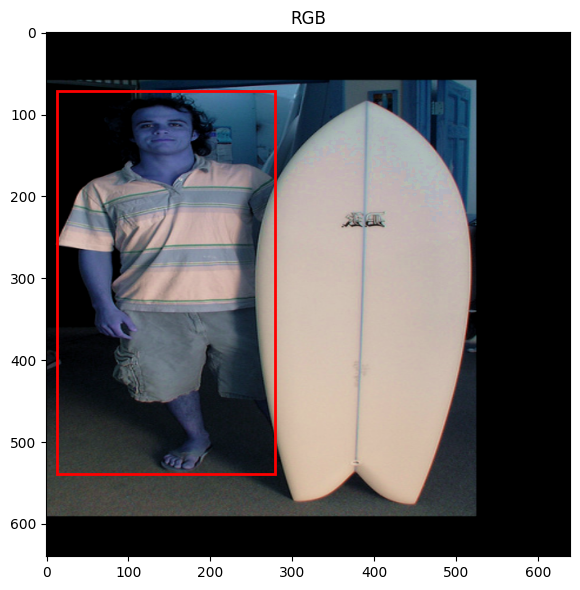

In [ ]:
img, _, boxes = train_dataset[1001]

print("num boxes:", len(boxes))
visualize_sample(img, None, boxes)

## Model and Modules

In [ ]:
class Backbone(nn.Module):
    def __init__(self, in_ch=3, model_name="mobilenetv3_large_100", out_ch=256):
        super().__init__()

        self.model = timm.create_model(
            model_name,
            pretrained=True,
            features_only=True,
            out_indices=(2, 3, 4),  # stable pyramid levels
            in_chans=in_ch
        )

        self.channels = self.model.feature_info.channels()
        selected_channels = self.channels  # filtered by out_indices

        # unify channels
        self.proj = nn.ModuleList([
            nn.Conv2d(c, out_ch, 1) for c in selected_channels
        ])

        # refinement (adds depth)
        self.refine = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.SiLU(inplace=True),

                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.SiLU(inplace=True),
            )
            for _ in selected_channels
        ])

    def forward(self, x):
      feats = self.model(x)  # [P3, P4, P5]

      out = []
      for i, f in enumerate(feats):
          f = self.proj[i](f)
          f = self.refine[i](f)
          out.append(f)

      return out

In [ ]:
class ScalarConfidenceGate(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(c, c // 2, 1),
            nn.SiLU(inplace=True),
            nn.Conv2d(c // 2, c, 1)   # per-channel gating
        )

    def forward(self, x):
        w = torch.sigmoid(self.net(x))  # [0, 1]

        # residual-style gating (more stable)
        return x * (0.5 + w)   # range [0.5, 1.5]

In [ ]:
class SafeResidualFusion(nn.Module):
    def __init__(self, c):
        super().__init__()

        self.refine = nn.Sequential(
            nn.Conv2d(c * 2, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),

            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

        # learnable fusion weight
        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, base, new):
        fused = self.refine(torch.cat([base, new], dim=1))

        # table residual fusion
        return base + torch.sigmoid(self.alpha) * fused

## Wawelet Transformation and IR Component Specific Classes

In [ ]:
class WaveletDecompose(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.dwt = DWTForward(J=1, wave='haar')

        # learnable scaling
        self.low_proj = nn.Conv2d(c, c, 1)
        self.high_proj = nn.Conv2d(c * 3, c, 1)

    def forward(self, x):
        yl, yh = self.dwt(x)
        yh = yh[0]  # (B, C, 3, H/2, W/2)

        yh = yh.view(x.size(0), -1, yl.size(2), yl.size(3))

        # normalize and project
        yl = self.low_proj(yl)
        yh = self.high_proj(yh)

        return yl, yh

In [ ]:
class FrequencyMixer(nn.Module):
    def __init__(self, c):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Conv2d(c * 2, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
            nn.Conv2d(c, c, 1),
            nn.Sigmoid()
        )

        self.refine = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True)
        )

    def forward(self, low, high):
        w = self.gate(torch.cat([low, high], dim=1))

        fused = w * low + (1 - w) * high

        return fused + self.refine(fused)  # residual boost

In [ ]:
class EdgeEnhance(nn.Module):
    def __init__(self, c):
        super().__init__()

        # Sobel kernels
        kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32)
        ky = kx.t()

        self.register_buffer("kx", kx.view(1,1,3,3))
        self.register_buffer("ky", ky.view(1,1,3,3))

        # projection
        self.proj = nn.Conv2d(1, c, 1)

        # normalization
        self.bn = nn.BatchNorm2d(c)

        # learnable strength
        self.alpha = nn.Parameter(torch.tensor(0.2))

    def forward(self, ir):
        if ir is None:
            return None

        # Sobel gradients
        gx = F.conv2d(ir, self.kx, padding=1)
        gy = F.conv2d(ir, self.ky, padding=1)

        # magnitude
        edge = torch.sqrt(gx**2 + gy**2 + 1e-6)

        # normalize
        edge = edge / (edge.mean(dim=[2,3], keepdim=True) + 1e-6)

        # project to feature space
        edge = self.proj(edge)
        edge = self.bn(edge)

        # controlled scaling instead of tanh
        return torch.sigmoid(self.alpha) * edge

In [ ]:
class SpatialPoolingAttention(nn.Module):
    def __init__(self, c):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, c // 4, 3, padding=1),   # now 4 channels input
            nn.BatchNorm2d(c // 4),
            nn.SiLU(inplace=True),

            nn.Conv2d(c // 4, 1, 1)
        )

    def forward(self, x):
        # standard pooling
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)

        # directional signals
        gx = torch.mean(x, dim=2, keepdim=True)  # horizontal awareness
        gy = torch.mean(x, dim=3, keepdim=True)  # vertical awareness

        # expand to match H,W
        gx = gx.expand_as(avg)
        gy = gy.expand_as(avg)

        # combine all signals
        attn = torch.cat([avg, mx, gx, gy], dim=1)

        attn = torch.sigmoid(self.conv(attn))

        return x * (0.5 + attn)   # stable residual attention

In [ ]:
class FusionBlock(nn.Module):
    def __init__(self, c, use_ir=False, use_wavelet=False):
        super().__init__()

        self.use_ir = use_ir
        self.use_wavelet = use_wavelet

        # CORE
        self.conf = ScalarConfidenceGate(c)
        self.safe = SafeResidualFusion(c)
        self.spatial = SpatialPoolingAttention(c)

        # IR
        self.edge = EdgeEnhance(c)
        self.ir_proj = nn.Conv2d(1, c, 1)

        # adaptive IR gating
        self.ir_gate = nn.Sequential(
            nn.Conv2d(c * 2, c, 1),
            nn.Sigmoid()
        )

        #  WAVELET
        if self.use_wavelet:
            self.wave = WaveletDecompose(c)
            self.freq_mixer = FrequencyMixer(c)

    def forward(self, rgb, ir=None):
        # RGB BASE
        rgb = self.conf(rgb)
        fused = rgb


        # IR FUSION
        if self.use_ir and ir is not None:

            ir_resized = F.interpolate(
                ir, size=rgb.shape[-2:], mode='bilinear', align_corners=False
            )

            ir_feat = self.ir_proj(ir_resized)

            # main fusion (residual)
            fused = self.safe(fused, ir_feat)

            # EDGE GUIDANCE
            edge = self.edge(ir)
            if edge is not None:
                edge = F.interpolate(
                    edge, size=fused.shape[-2:], mode='bilinear', align_corners=False
                )

                # gated edge fusion
                w = self.ir_gate(torch.cat([fused, edge], dim=1))
                fused = fused * (1 - w) + edge * w

        # WAVELET (OPTIONAL)
        if self.use_wavelet and self.use_ir and ir is not None:

            r_low, r_high = self.wave(rgb)
            i_low, i_high = self.wave(ir)

            freq = self.freq_mixer(r_low + i_low, r_high + i_high)

            freq = F.interpolate(
                freq, size=fused.shape[-2:], mode='bilinear', align_corners=False
            )

            fused = fused + 0.1 * freq  # light residual

        # SPATIAL ATTENTION
        fused = self.spatial(fused)

        return fused

In [ ]:
class FusionBackbone(nn.Module):
    def __init__(self, use_ir=False, out_ch=256):
        super().__init__()

        self.use_ir = use_ir
        self.out_ch = out_ch

        # RGB backbone
        self.rgb = Backbone(in_ch=3, out_ch=out_ch)

        # now channels are FIXED
        ch = [out_ch, out_ch, out_ch]

        # fusion blocks
        self.fusion = nn.ModuleList([
            FusionBlock(c, use_ir=use_ir) for c in ch
        ])

        # IR pyramid (scale-aware)
        if use_ir:
            self.ir_downsample = nn.ModuleList([
                nn.Identity(),                 # P3
                nn.AvgPool2d(2),              # P4
                nn.AvgPool2d(4)               # P5
            ])

    def forward(self, rgb, ir=None):
        # RGB FEATURES
        rgb_feats = self.rgb(rgb)   # [P3, P4, P5]

        # RGB-ONLY MODE
        if not self.use_ir or ir is None:
            return rgb_feats


        # IR PREP (multi-scale)
        ir_feats = []
        for i in range(len(rgb_feats)):
            ir_scaled = self.ir_downsample[i](ir)
            ir_feats.append(ir_scaled)

        # FUSION
        fused = []
        for i in range(len(rgb_feats)):
            f = self.fusion[i](rgb_feats[i], ir_feats[i])
            fused.append(f)

        return fused

In [ ]:
class SimpleFPN(nn.Module):
    def __init__(self, c=256):
        super().__init__()

        # TOP-DOWN
        self.lat5 = nn.Conv2d(c, c, 1)
        self.lat4 = nn.Conv2d(c, c, 1)

        self.smooth4 = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

        self.smooth3 = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

        # BOTTOM-UP (PAN)
        self.down3 = nn.Conv2d(c, c, 3, stride=2, padding=1)
        self.down4 = nn.Conv2d(c, c, 3, stride=2, padding=1)

        self.out4 = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

        self.out5 = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

    def forward(self, feats):
        c3, c4, c5 = feats

        # TOP-DOWN
        p5 = c5

        p4 = c4 + F.interpolate(self.lat5(c5), scale_factor=2, mode="nearest")
        p4 = self.smooth4(p4)

        p3 = c3 + F.interpolate(self.lat4(p4), scale_factor=2, mode="nearest")
        p3 = self.smooth3(p3)

        # BOTTOM-UP
        p4 = p4 + self.down3(p3)
        p4 = self.out4(p4)

        p5 = p5 + self.down4(p4)
        p5 = self.out5(p5)

        return [p3, p4, p5]

In [ ]:
class YOLOHeadDFL(nn.Module):
    def __init__(self, channels, num_classes=1, reg_max=16):
        super().__init__()

        self.num_classes = num_classes
        self.reg_max = reg_max

        self.heads = nn.ModuleList([
            self._build_head(c) for c in channels
        ])

    def _build_head(self, c):
        return nn.ModuleDict({

            "stem": nn.Sequential(
                nn.Conv2d(c, c, 3, padding=1),
                nn.BatchNorm2d(c),
                nn.SiLU(inplace=True),

                nn.Conv2d(c, c, 3, padding=1),
                nn.BatchNorm2d(c),
                nn.SiLU(inplace=True),
            ),

            # DFL box: 4 * reg_max
            "box": nn.Conv2d(c, 4 * self.reg_max, 1),

            "obj": nn.Conv2d(c, 1, 1),
            "cls": nn.Conv2d(c, self.num_classes, 1),
        })

    def forward(self, feats):
        outs = []

        for head, x in zip(self.heads, feats):
            x = head["stem"](x)

            box = head["box"](x)   # [B, 4*reg_max, H, W]
            obj = head["obj"](x)
            cls = head["cls"](x)

            out = torch.cat([box, obj, cls], dim=1)
            outs.append(out)

        return outs

In [ ]:
class FullModel(nn.Module):
    def __init__(self, num_classes=1, use_ir=False):
        super().__init__()

        self.use_ir = use_ir

        # backbone
        self.backbone = FusionBackbone(use_ir=use_ir)

        self.out_ch = 256

        # FPN
        self.fpn = SimpleFPN(self.out_ch)

        # head (must match FPN!)
        self.detector = YOLOHeadDFL([self.out_ch] * 3, num_classes)

    def forward(self, rgb, ir=None):

        feats = self.backbone(rgb, ir)   # → [256,256,256]

        feats = self.fpn(feats)          # → [256,256,256]

        preds = self.detector(feats)

        return preds

In [ ]:
model = FullModel().cuda()

rgb = torch.randn(2,3,256,256).cuda()


out = model(rgb)

for o in out:
    print(o.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

torch.Size([2, 66, 32, 32])
torch.Size([2, 66, 16, 16])
torch.Size([2, 66, 8, 8])


## Train Utils

In [ ]:
def bbox_ciou_batch(box1, box2):
    b1_x1 = box1[:, 0] - box1[:, 2] / 2
    b1_y1 = box1[:, 1] - box1[:, 3] / 2
    b1_x2 = box1[:, 0] + box1[:, 2] / 2
    b1_y2 = box1[:, 1] + box1[:, 3] / 2

    b2_x1 = box2[:, 0] - box2[:, 2] / 2
    b2_y1 = box2[:, 1] - box2[:, 3] / 2
    b2_x2 = box2[:, 0] + box2[:, 2] / 2
    b2_y2 = box2[:, 1] + box2[:, 3] / 2

    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter = (inter_x2 - inter_x1).clamp(min=0) * \
            (inter_y2 - inter_y1).clamp(min=0)

    area1 = (b1_x2 - b1_x1).clamp(min=1e-6) * (b1_y2 - b1_y1).clamp(min=1e-6)
    area2 = (b2_x2 - b2_x1).clamp(min=1e-6) * (b2_y2 - b2_y1).clamp(min=1e-6)

    union = area1 + area2 - inter + 1e-6
    iou = inter / union

    center_dist = (box1[:, 0] - box2[:, 0])**2 + (box1[:, 1] - box2[:, 1])**2

    enc_x1 = torch.min(b1_x1, b2_x1)
    enc_y1 = torch.min(b1_y1, b2_y1)
    enc_x2 = torch.max(b1_x2, b2_x2)
    enc_y2 = torch.max(b1_y2, b2_y2)

    enc_diag = (enc_x2 - enc_x1)**2 + (enc_y2 - enc_y1)**2 + 1e-6

    v = (4 / (3.14159265**2)) * torch.pow(
        torch.atan(box1[:, 2] / (box1[:, 3] + 1e-6)) -
        torch.atan(box2[:, 2] / (box2[:, 3] + 1e-6)), 2
    )

    alpha = v / (1 - iou + v + 1e-6)

    ciou = iou - (center_dist / enc_diag) - alpha * v

    return torch.clamp(ciou, -1.0, 1.0)

In [ ]:
# GRID
def make_grid(H, W, device):
    y, x = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing='ij'
    )
    return x.reshape(-1), y.reshape(-1)  # [HW]


In [ ]:
# DFL DECODE (ALL PIXELS)
def dfl_decode_all(box_pred, reg_max):
    B, _, H, W = box_pred.shape

    box_pred = box_pred.view(B, 4, reg_max, H, W)
    box_pred = torch.softmax(box_pred, dim=2)

    proj = torch.arange(reg_max, device=box_pred.device).float()
    dist = (box_pred * proj.view(1,1,-1,1,1)).sum(dim=2)

    return dist  # [B,4,H,W]

In [ ]:
# LTRB → XYWH (ALL)
def ltrb_to_xywh_all(dist, H, W):
    B = dist.shape[0]
    device = dist.device

    x, y = torch.meshgrid(
        torch.arange(W, device=device),
        torch.arange(H, device=device),
        indexing='xy'
    )

    cx = (x + 0.5) / W
    cy = (y + 0.5) / H

    cx = cx.unsqueeze(0)
    cy = cy.unsqueeze(0)

    l, t, r, b = dist[:,0], dist[:,1], dist[:,2], dist[:,3]

    x1 = cx - l / W
    y1 = cy - t / H
    x2 = cx + r / W
    y2 = cy + b / H

    w = x2 - x1
    h = y2 - y1
    xc = x1 + w / 2
    yc = y1 + h / 2

    return torch.stack([xc, yc, w, h], dim=1)  # [B,4,H,W]

In [ ]:
# DFL LOSS (VECTOR)
def dfl_loss(pred, target, reg_max):
    pred = pred.view(-1, reg_max)
    target = target.clamp(0, reg_max - 1 - 1e-3)

    left = target.long()
    right = left + 1

    wl = right.float() - target
    wr = 1 - wl

    logp = F.log_softmax(pred, dim=1)

    loss = (
        -logp[torch.arange(len(left)), left] * wl
        -logp[torch.arange(len(left)), right] * wr
    )

    return loss.mean()

In [ ]:
# MAIN LOSS (YOLOv8-STYLE)
def detection_loss_yolov8(preds, targets):

    reg_max = 16

    total_box = 0
    total_obj = 0
    total_cls = 0
    total_dfl = 0

    for p in preds:

        B, _, H, W = p.shape
        HW = H * W

        box_pred = p[:, :4 * reg_max]
        obj_pred = p[:, 4 * reg_max:4 * reg_max + 1]
        cls_pred = p[:, 4 * reg_max + 1:]

        # decode ALL predictions once
        dist = dfl_decode_all(box_pred, reg_max)
        pred_boxes = ltrb_to_xywh_all(dist, H, W)  # [B,4,H,W]

        obj_target = torch.zeros_like(obj_pred)
        cls_target = torch.zeros_like(cls_pred)

        x_idx, y_idx = make_grid(H, W, p.device)

        for b in range(B):

            if len(targets[b]) == 0:
                continue

            pred_boxes_flat = pred_boxes[b].view(4, -1).permute(1,0)  # [HW,4]
            cls_flat = cls_pred[b].view(cls_pred.shape[1], -1)

            gt = targets[b]  # [N,5]

            gt_boxes = gt[:, 1:]
            gt_cls = gt[:, 0].long()


            # COST MATRIX (vectorized)
            num_gt = gt_boxes.shape[0]

            pred_boxes_exp = pred_boxes_flat.unsqueeze(0).repeat(num_gt,1,1)
            gt_boxes_exp = gt_boxes.unsqueeze(1).repeat(1,HW,1)

            ciou = bbox_ciou_batch(
                pred_boxes_exp.reshape(-1,4),
                gt_boxes_exp.reshape(-1,4)
            ).view(num_gt, HW)

            iou_loss = 1 - ciou

            cls_scores = cls_flat[gt_cls]  # [num_gt, HW]
            cls_loss = F.binary_cross_entropy_with_logits(
                cls_scores, torch.ones_like(cls_scores)
            )

            cost = iou_loss + 0.5 * cls_loss

            # =====================
            # DYNAMIC K MATCHING
            # =====================
            matching = torch.zeros_like(cost)

            for i in range(num_gt):
                topk = min(20, HW)  # increased candidate pool

                topk_iou = torch.topk(ciou[i], topk).values

                # stronger dynamic K
                k = int(topk_iou.sum().item() * 1.5)
                k = max(3, min(k, 30))  # clamp

                # use cost (not only IoU)
                _, idx = torch.topk(cost[i], k, largest=False)

                matching[i, idx] = 1.0

            # resolve conflicts
            anchor_match = matching.sum(0)
            if (anchor_match > 1).any():
                min_cost_idx = cost[:, anchor_match > 1].argmin(0)
                matching[:, anchor_match > 1] *= 0
                matching[min_cost_idx, anchor_match > 1] = 1

            # =====================
            # BUILD TARGETS
            # =====================
            pos_idx = matching.sum(0) > 0

            obj_target[b, 0].view(-1)[pos_idx] = 1.0

            matched_gt = matching[:, pos_idx].argmax(0)

            cls_target_flat = cls_target[b].view(cls_pred.shape[1], -1)

            cls_target_flat[:, pos_idx] = 0
            cls_target_flat[gt_cls[matched_gt], pos_idx] = 1
            # =====================
            # BOX LOSS
            # =====================
            pos_boxes = pred_boxes_flat[pos_idx]
            target_boxes = gt_boxes[matched_gt]

            ciou_pos = bbox_ciou_batch(pos_boxes, target_boxes)

            total_box += (1 - ciou_pos).mean()

            # =====================
            # DFL LOSS (vectorized)
            # =====================
            pos_indices = pos_idx.nonzero().squeeze(1)

            pred_dist = box_pred[b].view(4, reg_max, H, W)
            pred_dist = pred_dist.permute(2,3,0,1).reshape(-1,4,reg_max)

            pred_dist_pos = pred_dist[pos_indices]

            # convert GT → ltrb
            cx = (x_idx[pos_indices] + 0.5) / W
            cy = (y_idx[pos_indices] + 0.5) / H

            x1 = target_boxes[:,0] - target_boxes[:,2]/2
            y1 = target_boxes[:,1] - target_boxes[:,3]/2
            x2 = target_boxes[:,0] + target_boxes[:,2]/2
            y2 = target_boxes[:,1] + target_boxes[:,3]/2

            l = (cx - x1) * W
            t = (cy - y1) * H
            r = (x2 - cx) * W
            b = (y2 - cy) * H

            target_ltrb = torch.stack([l,t,r,b], dim=1)

            total_dfl += dfl_loss(
                pred_dist_pos.reshape(-1, reg_max),
                target_ltrb.reshape(-1),
                reg_max
            )

        total_obj += F.binary_cross_entropy_with_logits(obj_pred, obj_target)
        total_cls += F.binary_cross_entropy_with_logits(cls_pred, cls_target)

    total_loss = (
      2.5 * total_box +
      1.0 * total_obj +
      0.5 * total_cls +
      1.0 * total_dfl
    )

    return total_loss, total_box, total_obj

In [ ]:
# =====================
# EMA
# =====================
class ModelEMA:
    def __init__(self, model, decay=0.9998):
        self.ema = type(model)(num_classes=1, use_ir=False).to(device)
        self.ema.load_state_dict(model.state_dict())
        self.ema.eval()

        self.decay = decay
        self.updates = 0

        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        d = self.decay * (1 - torch.exp(torch.tensor(-self.updates / 2000.0)))

        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=1 - d)

## Train Loop

In [ ]:
def evaluate_metrics(preds, targets,
                     conf_thres=0.3,
                     iou_thres=0.5):

    tp = 0
    fp = 0
    fn = 0

    for pred, gt in zip(preds, targets):

        boxes = decode_predictions(
            [pred.unsqueeze(0)],
            conf_thres=conf_thres
        )

        boxes = apply_nms(
            boxes,
            conf_thres,
            iou_thres
        )

        gt_boxes = gt[:,1:] if len(gt) else torch.zeros((0,4))

        matched = set()

        for pb in boxes:

            pbox = torch.tensor(pb[:4]).unsqueeze(0)

            best_iou = 0
            best_gt = -1

            for i, g in enumerate(gt_boxes):

                if i in matched:
                    continue

                iou = bbox_ciou_batch(
                    pbox,
                    g.unsqueeze(0)
                ).item()

                if iou > best_iou:
                    best_iou = iou
                    best_gt = i

            if best_iou > 0.5:
                tp += 1
                matched.add(best_gt)
            else:
                fp += 1

        fn += len(gt_boxes) - len(matched)

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)

    map50 = precision * recall

    return precision, recall, map50

In [ ]:
# =====================
# SETUP
# =====================
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

model = FullModel(num_classes=1, use_ir=False).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

scaler = torch.amp.GradScaler("cuda")

epochs = 60
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,
    total_steps=epochs * len(train_loader),
    pct_start=0.1
)

best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)


FREEZE_EPOCHS = 10

ema = ModelEMA(model)

# =====================
# FREEZE BACKBONE
# =====================
for p in model.backbone.parameters():
    p.requires_grad = False


train_losses = []
val_losses = []

# =====================
# TRAIN LOOP
# =====================
for epoch in range(epochs):

    if epoch == FREEZE_EPOCHS:
        print("🔓 Unfreezing backbone...")
        for p in model.backbone.parameters():
            p.requires_grad = True

    # ---------------------
    # TRAIN
    # ---------------------
    model.train()
    train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]")

    for step, batch in enumerate(train_bar):

        if batch is None:
            continue

        rgb, ir, targets = batch
        rgb = rgb.to(device, non_blocking=True)
        targets = [t.to(device) for t in targets]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):

            preds = model(rgb)

            loss, box_loss, obj_loss = detection_loss_yolov8(
                preds, targets
            )

        if not torch.isfinite(loss):
            print("⚠️ Skipping bad batch")
            continue

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        # EMA update
        ema.update(model)

        train_loss += loss.item()

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "box": f"{box_loss.item():.4f}" if torch.is_tensor(box_loss) else box_loss,
            "obj": f"{obj_loss.item():.4f}" if torch.is_tensor(obj_loss) else obj_loss,
            "avg": f"{train_loss / (step + 1):.4f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.6f}"
        })

    train_loss /= max(1, len(train_loader))

    # ---------------------
    # VALIDATION (EMA MODEL)
    # ---------------------
    ema.ema.eval()
    val_loss = 0.0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [VAL]")

    with torch.no_grad():
        for step, batch in enumerate(val_bar):

            if batch is None:
                continue

            rgb, ir, targets = batch
            rgb = rgb.to(device, non_blocking=True)
            targets = [t.to(device) for t in targets]

            with torch.amp.autocast("cuda", enabled=(device == "cuda")):

                preds = ema.ema(rgb)

                loss, _, _ = detection_loss_yolov8(preds, targets)

            if not torch.isfinite(loss):
                continue

            val_loss += loss.item()

            val_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "avg": f"{val_loss / (step + 1):.4f}"
            })

    val_loss /= max(1, len(val_loader))


    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"\nEpoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f}")

    # =====================
    # CHECKPOINTS
    # =====================

    # periodic
    if (epoch + 1) % 10 == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": ema.ema.state_dict(),  #  EMA weights
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
        }, f"checkpoints/epoch_{epoch+1}.pth")

        print(f"💾 Saved checkpoint {epoch+1}")

    # best
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": ema.ema.state_dict(),  #  EMA weights
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "val_loss": val_loss,
        }, "checkpoints/best.pth")

        print(f"✅ New best model at epoch {epoch+1}")

Epoch 1/60 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]/tmp/ipykernel_4987/3906100981.py:88: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/60 [VAL]: 100%|██████████| 84/84 [00:15<00:00,  5.48it/s, loss=232.0374, avg=234.7506]



Epoch 1: Train=286.2992 | Val=234.7506
✅ New best model at epoch 1


Epoch 2/60 [VAL]: 100%|██████████| 84/84 [00:15<00:00,  5.47it/s, loss=207.0880, avg=207.3357]



Epoch 2: Train=228.7617 | Val=207.3357
✅ New best model at epoch 2


Epoch 3/60 [VAL]: 100%|██████████| 84/84 [00:15<00:00,  5.48it/s, loss=193.3618, avg=192.4854]


...


Epoch 58: Train=111.7464 | Val=119.6436


Epoch 59/60 [VAL]: 100%|██████████| 84/84 [00:15<00:00,  5.47it/s, loss=123.8614, avg=119.7145]



Epoch 59: Train=111.2675 | Val=119.7145


Epoch 60/60 [VAL]: 100%|██████████| 84/84 [00:15<00:00,  5.40it/s, loss=123.5996, avg=119.7641]



Epoch 60: Train=111.3886 | Val=119.7641
💾 Saved checkpoint 60


In [ ]:
!cp -r /content/drive/MyDrive/coco/checkpoints /content/drive/MyDrive/

In [ ]:
!zip -r /content/drive/MyDrive/checkpoints.zip /content/drive/MyDrive/coco/checkpoints

  adding: content/drive/MyDrive/coco/checkpoints/ (stored 0%)
  adding: content/drive/MyDrive/coco/checkpoints/epoch_50.pth (deflated 9%)
  adding: content/drive/MyDrive/coco/checkpoints/epoch_60.pth (deflated 9%)
  adding: content/drive/MyDrive/coco/checkpoints/epoch_30.pth (deflated 9%)
  adding: content/drive/MyDrive/coco/checkpoints/epoch_10.pth (deflated 8%)
  adding: content/drive/MyDrive/coco/checkpoints/epoch_40.pth (deflated 9%)
  adding: content/drive/MyDrive/coco/checkpoints/.ipynb_checkpoints/ (stored 0%)
  adding: content/drive/MyDrive/coco/checkpoints/epoch_20.pth (deflated 9%)
  adding: content/drive/MyDrive/coco/checkpoints/best.pth (deflated 9%)


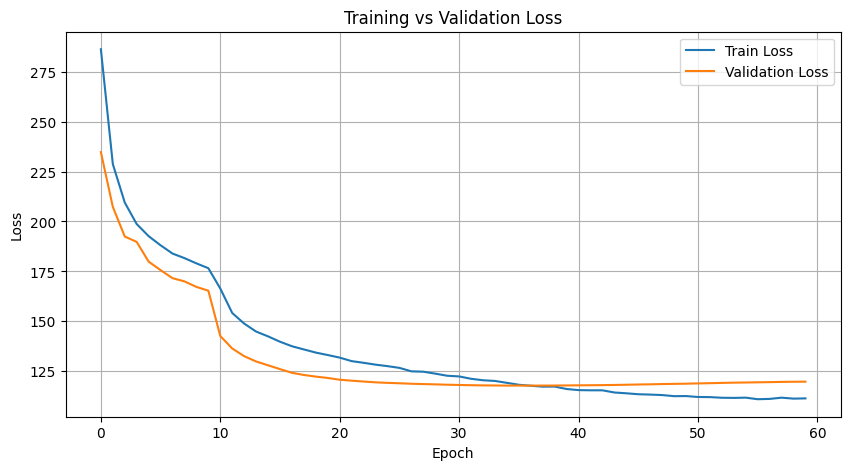

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

## Visual Testing

In [ ]:
def decode_predictions(preds, reg_max=16, conf_thres=0.3):
    boxes = []

    for p in preds:
        B, _, H, W = p.shape
        p = p[0]  # single image

        box_pred = p[:4 * reg_max]
        obj_pred = p[4 * reg_max]
        cls_pred = p[4 * reg_max + 1:]

        # ===== DFL decode =====
        box_pred = box_pred.view(4, reg_max, H, W)
        prob = torch.softmax(box_pred, dim=1)

        proj = torch.arange(reg_max, device=p.device).view(1, reg_max, 1, 1)
        dist = (prob * proj).sum(dim=1)  # [4,H,W]

        # ===== grid =====
        y, x = torch.meshgrid(
            torch.arange(H, device=p.device),
            torch.arange(W, device=p.device),
            indexing='ij'
        )

        cx = (x + 0.5) / W
        cy = (y + 0.5) / H

        l, t, r, b = dist

        x1 = cx - l / W
        y1 = cy - t / H
        x2 = cx + r / W
        y2 = cy + b / H

        w = x2 - x1
        h = y2 - y1
        xc = x1 + w / 2
        yc = y1 + h / 2

        obj = torch.sigmoid(obj_pred)

        # ===== threshold =====
        mask = obj > conf_thres
        ys, xs = mask.nonzero(as_tuple=True)

        for y_i, x_i in zip(ys, xs):
            score = obj[y_i, x_i].item()

            boxes.append([
                xc[y_i, x_i].item(),
                yc[y_i, x_i].item(),
                w[y_i, x_i].item(),
                h[y_i, x_i].item(),
                score
            ])

    return boxes

In [ ]:
def draw_boxes(image, boxes):
    h, w = image.shape[:2]

    for (xc, yc, bw, bh, score) in boxes:

        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(image, f"{score:.2f}",
                    (x1, max(0, y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (0,255,0), 1)

    return image

In [ ]:
def apply_nms(boxes, conf_thres=0.3, iou_thres=0.5):

    if len(boxes) == 0:
        return []

    boxes = torch.tensor(boxes)

    scores = boxes[:, 4]
    mask = scores > conf_thres

    boxes = boxes[mask]
    scores = scores[mask]

    if boxes.shape[0] == 0:
        return []

    # xywh → xyxy
    xyxy = torch.zeros((boxes.shape[0], 4))
    xyxy[:, 0] = boxes[:, 0] - boxes[:, 2] / 2
    xyxy[:, 1] = boxes[:, 1] - boxes[:, 3] / 2
    xyxy[:, 2] = boxes[:, 0] + boxes[:, 2] / 2
    xyxy[:, 3] = boxes[:, 1] + boxes[:, 3] / 2

    keep = ops.nms(xyxy, scores, iou_thres)

    final = boxes[keep]

    return final.tolist()

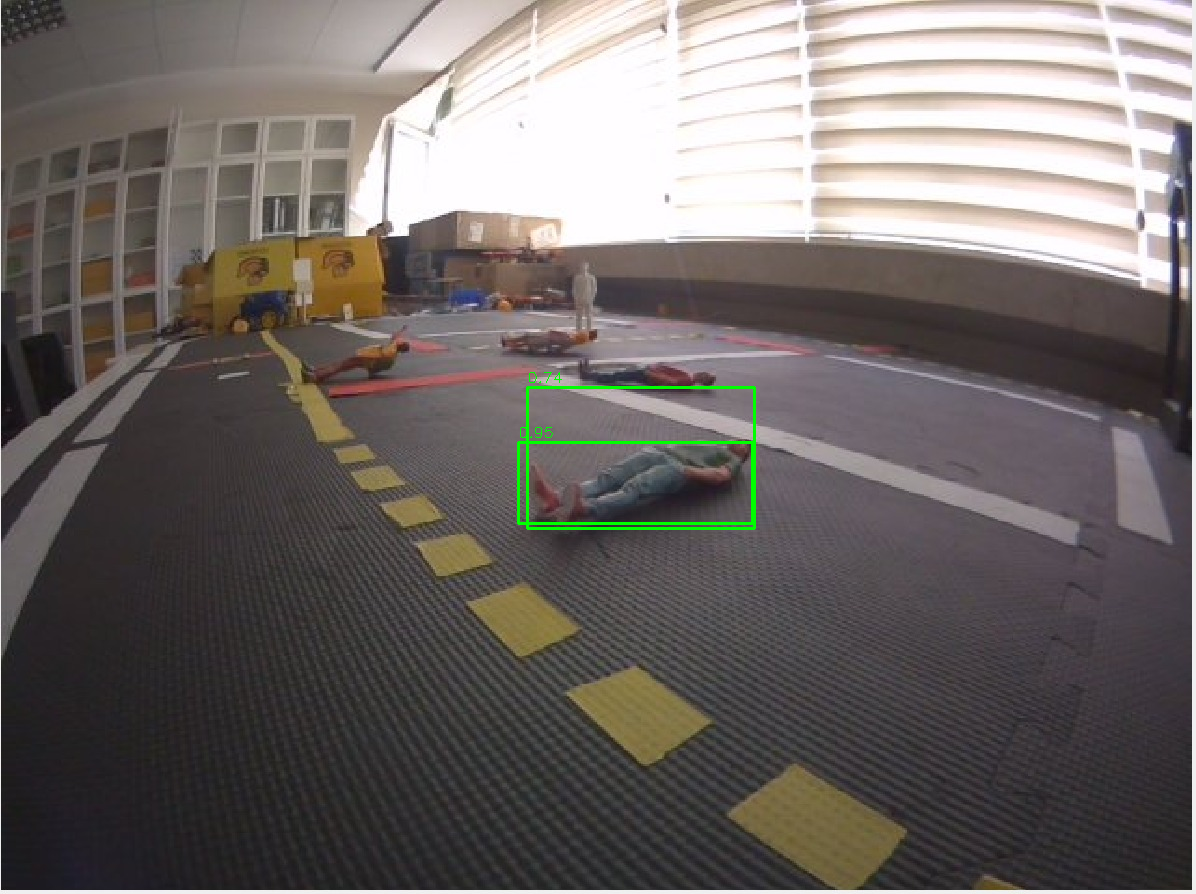

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

model = FullModel(num_classes=1, use_ir=False).to(device)
model.eval()
model.load_state_dict(torch.load("/content/drive/MyDrive/coco/checkpoints/best.pth")["model_state_dict"])


img = cv2.imread("/content/toplu_yatis.jpeg")
img_resized = cv2.resize(img, (480, 480))

tensor = torch.from_numpy(img_resized).permute(2,0,1).float()/255.0
tensor = tensor.unsqueeze(0).to(device)

with torch.no_grad():
    preds = model(tensor, None)

boxes = decode_predictions(preds,16,0.4)
boxes = apply_nms(boxes,0.5, 0.6)

out = draw_boxes(img.copy(), boxes)

cv2_imshow(out)